
## Introduction

The aim of this assignment is to give you the experience of using real public data and create your own report. The raw data are available in different formats and structures and often contain undesired formatting errors. Statistical data are continuously updated and may even provide API's to stream data instead of taking snapshots. We will be using snapshots in this assignment but to streamline the analysis around possible future snapshots you'll be implementing a 'data-specific' Python class with appropriate methods for data manipulation and visualisation.

## Data: Emissions to air by the Dutch economy

In this assignment we will be using *Emissions to air by the Dutch economy* [CBS StatLine](https://opendata.cbs.nl/portal.html?_la=en&_catalog=CBS&tableId=83300ENG&_theme=1129). The metadata (`83300ENG_metadata.csv`) and the raw data (`83300ENG_UntypedDataSet_29032023_184145.csv`) are included the git repository under `08_dv/assignment_c/data` but the latest can also be downloaded from [here](https://opendata.cbs.nl/portal.html?_la=en&_catalog=CBS&tableId=83300ENG&_theme=1129) or from




## Assignment

#### 1) Class GWP [4p].

- Create the class `GWP` (Global Warming Potential) which is initialised with raw data along with the meta information.
- Create class attributes [emissions](emissions.md) and [emission_sources](emission_sources.md) from the metadata.
- Add variables to the :
    - `Date` :  of type timestamp created from the variable `Periods`
    - `Source` : holding the `Title` values of the emission source in the metadata.

In [1130]:
import pandas as pd
import seaborn as sb
import numpy as np

class GWP:
    def __init__(self, path, meta_path):
        self.path = path
        self.meta_data = meta_path
        self.data = pd.read_csv(self.path, sep=";")
        self.meta_path = pd.read_csv(self.meta_data, sep=";", skiprows=9, header=None)

        # emission sources
        emission_sources=self.meta_path.loc[19:77][self.meta_path.columns[0:3]].reset_index(drop=True)
        emission_sources.columns=["DutchEconomy", "Title", "Description"]
        self.emission_sources=emission_sources

        #emissions
        emission=self.meta_path.loc[0:16][self.meta_path.columns[[4,5,6,9]]]
        emission.columns=[" ","Title", "Description", "Unit"]
        self.emission=emission

        Date = pd.Series([pd.Timestamp(year=int(v[0:4]), month=12, day=31) for v in self.data['Periods']])
        self.data["Date"] = Date

        self.data["Source"] = [None]*self.data.shape[0]
        for i in range(self.data.shape[0]):
            code=self.data["DutchEconomy"].loc[i]
            self.data["Source"][i] = list(self.emission_sources["Title"][self.emission_sources["DutchEconomy"]==code])[0]

    def plot(self, emission, source):
        Sources=[]
        for j in source:
            if not(j.isdigit()):
                lst=[v for v in self.emission_sources['Title'] if ((j.capitalize() in v) or (j in v))]
                [Sources.append(l) for l in lst]
            else:
                for a in range(len(self.emission_sources)):
                    if (j in self.emission_sources['DutchEconomy'][a]):
                        Sources.append(self.emission_sources['Title'][a])
        df_new=self.data[emission+["Date", "Source"]]
        temp=pd.DataFrame()
        for i in Sources:
            temp=pd.concat([df_new[df_new.Source==i],temp],ignore_index=True)

        df_long=pd.melt(temp, id_vars=['Date', 'Source'], value_vars=emission, var_name="Emission")
        sb.set_style("darkgrid")
        pl=sb.relplot(df_long, x='Date', y='value', kind='line', errorbar=None, hue='Source', style='Emission') 
        pl.set_xlabels("Year")
        pl.set_ylabels("Emission (MCM)")

    def get_emmission(self, emission_category):
        if emission_category=='ghg':
            return list(self.data.columns[3:9]) + [self.data.columns[19]]
        elif emission_category=='acid':
            return list(self.data.columns[9:13])
        elif emission_category=='ozone':
            return [self.data.columns[13]]
        elif emission_category=='air':
            return list(self.data.columns[14:17])
        else:
            raise InputError("The emission category should be one of {ghg, acid, ozone, air}.")

    def summary(self, date=''):
        if date=='':
            print(f"Data path: {self.path}, Meta data path: {self.meta_data}")
            print(f"Shape of the data: {self.data.shape}")
            print(f"Number of emission sources: {self.emission_sources.shape[0]}")
            print(f"Number of emission variables: {self.emission.shape[0]}")
            print(f"First date: {pd.to_datetime(self.data.Date).min()} and latest date: {pd.to_datetime(self.data.Date).max()}")
        else:
            emissions_rows = list(self.data.columns)[3:17] + [self.data.columns[19]]
            out=pd.DataFrame()
            self.data["Year"] = self.data.Date.dt.year

            if type(date)==tuple:
                for e in emissions_rows:
                    minimum=min(self.data[e][((self.data.Year>=date[0]) & (self.data.Year<=date[1]))])
                    q1=np.quantile(self.data[e][((self.data.Year>=date[0]) & (self.data.Year<=date[1]))], q=0.25)
                    q2=np.quantile(self.data[e][((self.data.Year>=date[0]) & (self.data.Year<=date[1]))], q=0.5)
                    m=np.mean(self.data[e][((self.data.Year>=date[0]) & (self.data.Year<=date[1]))])
                    q3=np.quantile(self.data[e][((self.data.Year>=date[0]) & (self.data.Year<=date[1]))], q=0.75)
                    maximum=max(self.data[e][((self.data.Year>=date[0]) & (self.data.Year<=date[1]))])
                    out=pd.concat([out, pd.Series({'minimum':minimum, "Q1":q1, "Q2":q2, "mean":m, "Q3":q3, "maximum":maximum}, name=e)], axis=1)
                print(np.transpose(out))
            elif type(date)==int:
                for e in emissions_rows:
                    minimum=min(self.data[e][self.data.Year==date])
                    q1=np.quantile(self.data[e][self.data.Year==date], q=0.25)
                    q2=np.quantile(self.data[e][self.data.Year==date], q=0.5)
                    m=np.mean(self.data[e][self.data.Year==date])
                    q3=np.quantile(self.data[e][self.data.Year==date], q=0.75)
                    maximum=max(self.data[e][self.data.Year==date])
                    out=pd.concat([out, pd.Series({'minimum':minimum, "Q1":q1, "Q2":q2, "mean":m, "Q3":q3, "maximum":maximum}, name=e)], axis=1)
                print(np.transpose(out))
            

In [ ]:
gwp = GWP(path="data/83300ENG_UntypedDataSet_29032023_184145.csv", meta_path='data/83300ENG_metadata.csv')

In [6]:
gwp.emission.head()

,Title,Description,Unit
TotalCO2_1,Total CO2,Carbon dioxide.\nGreenhouse gas (causes the te...,mln kgs
CO2ExclBiomass_2,CO2 excl. biomass,Carbon dioxide.excluding emissions from biomas...,mln kgs
CO2Biomass_3,CO2 biomass,Carbon dioxide.emissions from biomass.\nGreenh...,mln kgs
N2O_4,N2O,Laughing gas/dinitrogen oxide.\nN2O is formed ...,mln kgs
CH4_5,CH4,Methane (= natural gas).\nAmong other causes C...,mln kgs


In [7]:
gwp.emission_sources.head()

,Title,Description
DutchEconomy,,
1050010,Total private households,Private households:\nA private household gathe...
B000579,Total Dutch economy,"This includes emissions from households, from ..."
B000580,Transport activity by private households,Air emissions caused by transportation activit...
B000581,Other private households,Emissions to air caused by other activities of...
T001081,A-U All economic activities,All economic activities


In [8]:
gwp.data.dtypes

ID                                      int64
DutchEconomy                           object
Periods                                object
TotalCO2_1                              int64
CO2ExclBiomass_2                        int64
CO2Biomass_3                          float64
N2O_4                                 float64
CH4_5                                 float64
GreenhouseGasEquivalents_6              int64
NOx_7                                 float64
SO2_8                                 float64
NH3_9                                 float64
AcidificationEquivalents_10           float64
CFK12Equivalents_11                   float64
CO_12                                 float64
NMVOC_13                              float64
PM10_14                               float64
Date                           datetime64[ns]
Source                                 object
HFC                                   float64
dtype: object

#### 2) Greenhouse equivalents [1p].

The [greenhouse equivalents](https://www.cbs.nl/en-gb/news/2020/19/uitstoot-broeikasgassen-3-procent-lager-in-2019/co2-equivalents) is a measure to relate othe other gases to CO2.

- Convert `N2O_4` and `CH4_5` in `GWP.data` to CO2 equivalents.
- Add a new variable `HFC` to the GWP.data which contains the fluorine (chlorine) gases CO2 equivalents. HFC stands for hydrofluorocarbons (see [Fluorinated gases](https://en.wikipedia.org/wiki/Fluorinated_gases)). The emission has been added to the total greenhouse gas equivalent but not specified as separate variable. See also *greenhouse gas equivalents* description in the metadata.

In [1132]:
N20_Equiv = gwp.data["N2O_4"]*298
CH4_Equiv = gwp.data["CH4_5"]*25
total_CO2_Equiv = gwp.data["TotalCO2_1"] + N20_Equiv + CH4_Equiv
gwp.data["HFC"] = gwp.data["GreenhouseGasEquivalents_6"] - total_CO2_Equiv 

#### 3) Implement a plot method that produces the figure below. [3p]

**Synopsis:** &nbsp; &nbsp;**<tt>GWP.plot(emission, source)</tt>**

    - emission: is a list of emissions to be drawn
    - source: list of Dutch economy sector id's or a pattern

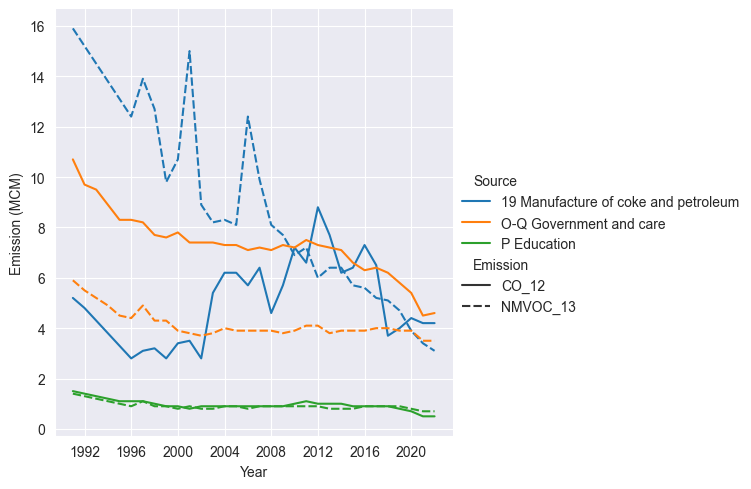

In [1126]:
# my plot
gwp.plot(emission=['CO_12', 'NMVOC_13'],source=['education', 'government','320000' ]);

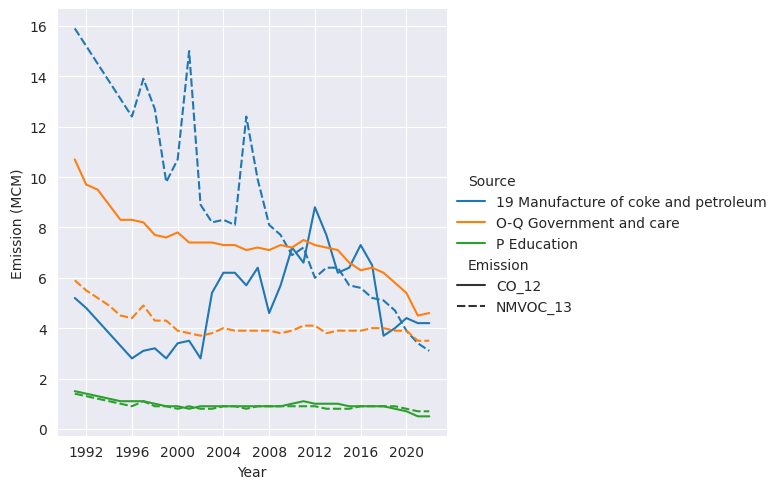

In [9]:
# teachers' plot
gwp.plot(emission=['CO_12', 'NMVOC_13'],source=['education', 'government','320000' ]);


#### 4) Emission categories [1p]

There are 4 categories of emissions:
   - Greenhouse gases (climate change) {TotalCO2_1, CO2ExclBiomass_2, CO2Biomass_3, N2O_4, CH4_5, GreenhouseGasEquivalents_6}
   - Acidification {NOx_7, SO2_8, NH3_9, AcidificationEquivalents_10}
   - Ozone layer depletion {CFK12Equivalents_11}
   - Other air pollution {CO_12, NMVOC_13, PM10_14, HFC}

Implement the method `get_emmission` with the following specification:

**Synopsis:** &nbsp; &nbsp;**<tt>GWP.get_emmission(emission_category)</tt>**

   - emission_category : {ghg, acid, ozone, air}
   - return value : list of variable names of the given category.


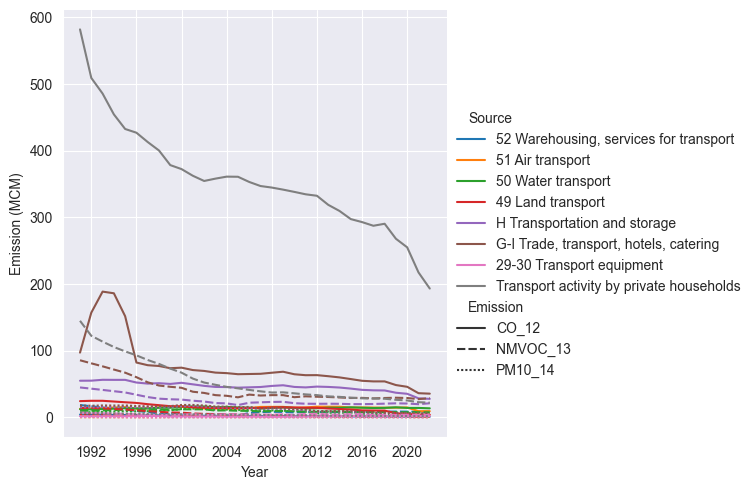

In [1127]:
# my plot
gwp.plot(emission=gwp.get_emmission('air'),source=['transport']);

# My method aims at locating all the Sources associated with the given key word (here 'transport'),
# hence my plot is way more busy than the original one.

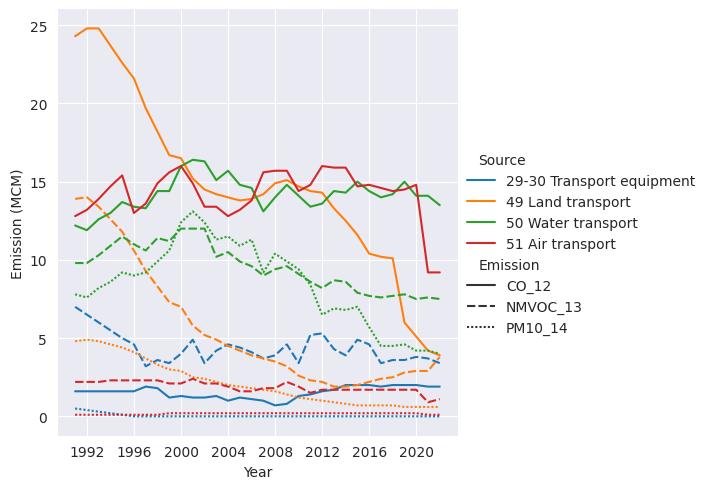

In [10]:
# teachers' plot
gwp.plot(emission=gwp.get_emmission('air'),source=['transport']);

#### 5) Summary [1p]

Implement the `summary` method which gives `general information` about the data such as:
- data and meta file paths
- shape of the data
- number of emission sources.
- number of emission variables
- first and latest date


**Synopsis:** &nbsp; &nbsp;**<tt>GWP.summary(date)</tt>**
   - `date`     : tuple of dates (min,[max]).

If `date` is given then print a DataFrame of descriptive statistics with columns {min, 1st quartile, 2nd quartile, mean 3rd quartile, max} and emission as row indices. In this case do not output the `general information`. Note, for the `date` method argument, in case 'max' is omitted then the summary is given for a single year.


In [1133]:
print(gwp.summary())

Data path: data/83300ENG_UntypedDataSet_29032023_184145.csv, Meta data path: data/83300ENG_metadata.csv
Shape of the data: (1888, 20)
Number of emission sources: 59
Number of emission variables: 17
First date: 1990-12-31 00:00:00 and latest date: 2021-12-31 00:00:00
None


In [1134]:
print(gwp.summary(date = (1997, 2015)))

                             minimum     Q1      Q2          mean       Q3   
TotalCO2_1                       0.0  460.0  1882.0  14574.089206   9692.0  \
CO2ExclBiomass_2                 0.0  382.0  1699.0  13872.382694   9309.0   
CO2Biomass_3                     0.0    0.6     6.0    701.715968    112.5   
N2O_4                            0.0    0.0     0.0      2.893934      0.3   
CH4_5                            0.0    0.1     0.4     40.406244      3.3   
GreenhouseGasEquivalents_6       0.0  512.0  2351.0  16816.855486  11108.0   
NOx_7                            0.0    0.7     4.9     43.329438     20.2   
SO2_8                            0.0    0.0     0.1     10.623104      2.9   
NH3_9                            0.0    0.0     0.1      7.669492      0.4   
AcidificationEquivalents_10      0.0    0.0     0.1      1.718376      0.7   
CFK12Equivalents_11              0.0    0.0     0.0     10.584924      0.1   
CO_12                            0.0    1.2     3.9     49.92827

In [1135]:
print(gwp.summary(date = (2004)))

                             minimum      Q1      Q2          mean        Q3   
TotalCO2_1                       0.0  526.00  2323.0  15091.983051   9183.00  \
CO2ExclBiomass_2                 0.0  416.00  1803.0  14506.084746   9177.00   
CO2Biomass_3                     0.0    0.15     4.2    585.891525     51.05   
N2O_4                            0.0    0.00     0.0      3.603390      0.30   
CH4_5                            0.0    0.10     0.4     40.022034      3.30   
GreenhouseGasEquivalents_6       0.0  571.50  2594.0  17311.033898  10451.50   
NOx_7                            0.0    0.85     5.0     46.555932     20.90   
SO2_8                            0.0    0.00     0.2     12.635593      2.60   
NH3_9                            0.0    0.00     0.1      8.128814      0.40   
AcidificationEquivalents_10      0.0    0.00     0.1      1.874576      0.75   
CFK12Equivalents_11              0.0    0.00     0.0      9.569492      0.00   
CO_12                            0.0    

#### 6) Bonus point

Add a new plot method to the class which gives a different kind of information than the one given in GWP.plot.